In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
import pandas as pd
#Load CSV
df=pd.read_csv('/content/drive/MyDrive/DSP/Task-1/scraped_data (3).csv')

In [62]:
df.head(50)

,Year,Quarter,Date of Sale,Product,Product Category,Quantity,Total Price,Total Profit,Payment Type,Customer ID,Location,Gender,Age Category
0,2024,1,2024-01-01,White Short Sleeve Oxford Shirt,Men → Shirts,1,€53.00,€20.14,Credit Card,3375,Dublin,Male,18-24
1,2024,1,2024-01-01,Black Skinny Fit Jeans with Stretch,Men → Jeans,1,€46.00,€18.40,CC,3997,Dublin,Female,25-34
2,2024,1,2024-01-01,1000 Thread Count Cotton Sateen Collection,Homeware → Bed Bath,3,€267.00,€93.45,Credit Card,6419,Tipperary,Female,35-44
3,2024,1,2024-01-01,Black Loose Fit Jeans with Stretch,Men → Jeans,1,€29.00,€11.60,Credit Card,18572,Cork,Female,35-44
4,2024,1,2024-01-01,Mola Headlamp,Homeware → Design,2,€86.00,€34.40,CC,15441,Donegal,Female,25-34
5,2024,1,2024-01-02,Pink Slim Fit Double Cuff Shirt,Men → Shirts,1,€29.00,€11.02,Credit Card,14644,Carlow,Female,35-44
6,2024,1,2024-01-02,Blue Floral Embroidered Mac,Children → Girls Wear,1,€35.00,€17.85,CC,5681,Sligo,Female,65
7,2024,1,2024-01-02,Navy Colourblock Crew and Jogger Set,Children → Boys Wear,2,€35.00,€17.85,Debit Card,11222,Clare,Female,35-44
8,2024,1,2024-01-02,Dark Blue Belted Jeans,Men → Jeans,1,€29.00,€11.60,Credit Card,7544,Limerick,Female,35-44
9,2024,1,2024-01-02,Black Single Cuff Shirt,Men → Shirts,1,€42.00,€15.96,Credit Card,12791,Dublin,Female,35-44


In [63]:
#Check the  Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Year              1800 non-null   int64 
 1   Quarter           1800 non-null   int64 
 2   Date of Sale      1800 non-null   object
 3   Product           1800 non-null   object
 4   Product Category  1800 non-null   object
 5   Quantity          1800 non-null   int64 
 6   Total Price       1800 non-null   object
 7   Total Profit      1800 non-null   object
 8   Payment Type      1800 non-null   object
 9   Customer ID       1800 non-null   int64 
 10  Location          1687 non-null   object
 11  Gender            1713 non-null   object
 12  Age Category      1783 non-null   object
dtypes: int64(4), object(9)
memory usage: 182.9+ KB




1.   Convert "Date of Sale" to datetime

*   Ensures proper date handling: Converting to datetime allows for date-based analysis such as monthly trends, seasonal sales.

*   Prevents errors: The errors='coerce' argument converts invalid entries into NaT (Not a Time), ensuring consistency. As I faced this error previously.


2.   Convert "Total Price" & "Total Profit" to Float


*   Removes currency symbols (€) and commas (,) that might interfere with numerical operations.
*   Enables calculations: Aggregation (sum, average), trend analysis, and comparisons require numerical data types.In ths case not needed.


3.   Convert "Quantity" to Integer

*   Ensures numerical correctness: Some entries might be stored as strings due to incorrect data entry.
*   Prevents errors in calculations: Using pd.to_numeric(errors='coerce') ensures that any non-numeric values are converted to NaN instead of causing errors and NaN is fixed later.








In [64]:
# Convert Date of Sale to datetime
df['Date of Sale'] = pd.to_datetime(df['Date of Sale'], errors='coerce')

# Convert Price and Profit columns by removing € and converting to float
df['Total Price'] = df['Total Price'].replace('[€,]', '', regex=True).astype(float)
df['Total Profit'] = df['Total Profit'].replace('[€,]', '', regex=True).astype(float)

# Convert Quantity to integer
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')


In [65]:
df

,Year,Quarter,Date of Sale,Product,Product Category,Quantity,Total Price,Total Profit,Payment Type,Customer ID,Location,Gender,Age Category
0,2024,1,2024-01-01,White Short Sleeve Oxford Shirt,Men → Shirts,1,53.0,20.14,Credit Card,3375,Dublin,Male,18-24
1,2024,1,2024-01-01,Black Skinny Fit Jeans with Stretch,Men → Jeans,1,46.0,18.40,CC,3997,Dublin,Female,25-34
2,2024,1,2024-01-01,1000 Thread Count Cotton Sateen Collection,Homeware → Bed Bath,3,267.0,93.45,Credit Card,6419,Tipperary,Female,35-44
3,2024,1,2024-01-01,Black Loose Fit Jeans with Stretch,Men → Jeans,1,29.0,11.60,Credit Card,18572,Cork,Female,35-44
4,2024,1,2024-01-01,Mola Headlamp,Homeware → Design,2,86.0,34.40,CC,15441,Donegal,Female,25-34
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,2024,4,2024-12-22,Lilac/Mint Long Sleeve Shirts,Children → Girls Wear,2,52.0,26.52,Credit Card,2734,Galway,Female,25-34
1796,2024,4,2024-12-22,Cream Vintage Bin,Homeware → Bed Bath,5,360.0,126.00,Credit Card,7019,Wicklow,Female,18-24
1797,2024,4,2024-12-22,Fancy Ballerina Shoes,Men → Shoes,3,129.0,58.05,Debit Card,6041,Louth,Male,25-34
1798,2024,4,NaT,Lilac/Mint Long Sleeve Shirts,Children → Girls Wear,2,52.0,26.52,Credit Card,3819,NaN,Female,25-34


**Reason for Replacing "CC" with "Credit Card"  and "Pay Pal" with "PayPal"in the "Payment Type" Column**


1.   Improves Readability & Clarity


*   "CC" is an abbreviation that might not be immediately clear to all users. Expanding it to "Credit Card" makes the data more interpretable, especially for reports or visualizations.

2.   Consistency in Data Representation


*   Other payment types might be written in full form (e.g., "Cash," "Debit Card"). Keeping all categories in a uniform format ensures better consistency in analysis and presentation.


*   "Pay Pal" and "PayPal" might be considered as different payment type so it may change the analysis




3.   Prevents Errors in Aggregation & Analysis


*   If both "CC", "Credit Card", "PayPal", "Pay Pal" exist as separate values in the dataset, they may be treated as distinct categories. Standardizing the naming ensures correct grouping and accurate insights when analyzing payment trends.








In [66]:
# Replace "CC" with "Credit Card" in the "Payment Type" column
df['Payment Type'] = df['Payment Type'].replace('CC', 'Credit Card')
df['Payment Type'] = df['Payment Type'].replace('Pay Pal', 'PayPal')
df

,Year,Quarter,Date of Sale,Product,Product Category,Quantity,Total Price,Total Profit,Payment Type,Customer ID,Location,Gender,Age Category
0,2024,1,2024-01-01,White Short Sleeve Oxford Shirt,Men → Shirts,1,53.0,20.14,Credit Card,3375,Dublin,Male,18-24
1,2024,1,2024-01-01,Black Skinny Fit Jeans with Stretch,Men → Jeans,1,46.0,18.40,Credit Card,3997,Dublin,Female,25-34
2,2024,1,2024-01-01,1000 Thread Count Cotton Sateen Collection,Homeware → Bed Bath,3,267.0,93.45,Credit Card,6419,Tipperary,Female,35-44
3,2024,1,2024-01-01,Black Loose Fit Jeans with Stretch,Men → Jeans,1,29.0,11.60,Credit Card,18572,Cork,Female,35-44
4,2024,1,2024-01-01,Mola Headlamp,Homeware → Design,2,86.0,34.40,Credit Card,15441,Donegal,Female,25-34
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,2024,4,2024-12-22,Lilac/Mint Long Sleeve Shirts,Children → Girls Wear,2,52.0,26.52,Credit Card,2734,Galway,Female,25-34
1796,2024,4,2024-12-22,Cream Vintage Bin,Homeware → Bed Bath,5,360.0,126.00,Credit Card,7019,Wicklow,Female,18-24
1797,2024,4,2024-12-22,Fancy Ballerina Shoes,Men → Shoes,3,129.0,58.05,Debit Card,6041,Louth,Male,25-34
1798,2024,4,NaT,Lilac/Mint Long Sleeve Shirts,Children → Girls Wear,2,52.0,26.52,Credit Card,3819,NaN,Female,25-34


**Explanation for Dropping the Columns**


1.   Product Category
*    This column  is redundant due to other product-related feature "Product Name" is used for specified analysis, it might not provide additional useful insights for the analysis.

2.   Customer ID

*   This column is a unique identifier for customers and does not contribute to the analysis of trends, correlations, or aggregate metrics.

3.   Date of Sale
*   If the analysis focuses on quarterly or categorical time trends like "Quarter" already present, the exact sale date might not be needed.

In [67]:
# Drop the "Product Category" column from the DataFrame.
df = df.drop('Product Category', axis=1)
df = df.drop('Customer ID', axis=1)
df = df.drop('Date of Sale', axis=1)

In [68]:
df

,Year,Quarter,Product,Quantity,Total Price,Total Profit,Payment Type,Location,Gender,Age Category
0,2024,1,White Short Sleeve Oxford Shirt,1,53.0,20.14,Credit Card,Dublin,Male,18-24
1,2024,1,Black Skinny Fit Jeans with Stretch,1,46.0,18.40,Credit Card,Dublin,Female,25-34
2,2024,1,1000 Thread Count Cotton Sateen Collection,3,267.0,93.45,Credit Card,Tipperary,Female,35-44
3,2024,1,Black Loose Fit Jeans with Stretch,1,29.0,11.60,Credit Card,Cork,Female,35-44
4,2024,1,Mola Headlamp,2,86.0,34.40,Credit Card,Donegal,Female,25-34
...,...,...,...,...,...,...,...,...,...,...
1795,2024,4,Lilac/Mint Long Sleeve Shirts,2,52.0,26.52,Credit Card,Galway,Female,25-34
1796,2024,4,Cream Vintage Bin,5,360.0,126.00,Credit Card,Wicklow,Female,18-24
1797,2024,4,Fancy Ballerina Shoes,3,129.0,58.05,Debit Card,Louth,Male,25-34
1798,2024,4,Lilac/Mint Long Sleeve Shirts,2,52.0,26.52,Credit Card,NaN,Female,25-34


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          1800 non-null   int64  
 1   Quarter       1800 non-null   int64  
 2   Product       1800 non-null   object 
 3   Quantity      1800 non-null   int64  
 4   Total Price   1800 non-null   float64
 5   Total Profit  1800 non-null   float64
 6   Payment Type  1800 non-null   object 
 7   Location      1687 non-null   object 
 8   Gender        1713 non-null   object 
 9   Age Category  1783 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 140.8+ KB


In [70]:
df

,Year,Quarter,Product,Quantity,Total Price,Total Profit,Payment Type,Location,Gender,Age Category
0,2024,1,White Short Sleeve Oxford Shirt,1,53.0,20.14,Credit Card,Dublin,Male,18-24
1,2024,1,Black Skinny Fit Jeans with Stretch,1,46.0,18.40,Credit Card,Dublin,Female,25-34
2,2024,1,1000 Thread Count Cotton Sateen Collection,3,267.0,93.45,Credit Card,Tipperary,Female,35-44
3,2024,1,Black Loose Fit Jeans with Stretch,1,29.0,11.60,Credit Card,Cork,Female,35-44
4,2024,1,Mola Headlamp,2,86.0,34.40,Credit Card,Donegal,Female,25-34
...,...,...,...,...,...,...,...,...,...,...
1795,2024,4,Lilac/Mint Long Sleeve Shirts,2,52.0,26.52,Credit Card,Galway,Female,25-34
1796,2024,4,Cream Vintage Bin,5,360.0,126.00,Credit Card,Wicklow,Female,18-24
1797,2024,4,Fancy Ballerina Shoes,3,129.0,58.05,Debit Card,Louth,Male,25-34
1798,2024,4,Lilac/Mint Long Sleeve Shirts,2,52.0,26.52,Credit Card,NaN,Female,25-34


In [71]:
# To Check Sataistical Summary
print(df.describe())

         Year      Quarter     Quantity  Total Price  Total Profit
count  1800.0  1800.000000  1800.000000  1800.000000   1800.000000
mean   2024.0     2.502222     1.507222    51.276833     22.073389
std       0.0     1.104338     1.026580    47.536511     18.423064
min    2024.0     1.000000    -1.000000     6.750000      3.080000
25%    2024.0     2.000000     1.000000    28.725000     11.250000
50%    2024.0     3.000000     1.000000    35.000000     17.640000
75%    2024.0     3.000000     2.000000    62.000000     26.520000
max    2024.0     4.000000    10.000000   432.000000    169.600000


**Handling negative values in Quantity**

1.   Ensures Data Integrity


*   Sales quantities should always be positive, as negative values might indicate data entry errors.
*   Negative values could result from incorrect transaction records, such as returns being recorded incorrectly.


2.   Prevents Misleading Analysis


*   Negative values can distort summary statistics (e.g., total sales, average quantity per purchase).
*   Visualizations and calculations, such as total revenue, may become inaccurate if negative values exist.



3.   Maintains Business Logic


*   Quantity represents the number of products sold, which should logically be positive or zero.
*   If negative values indicate returns, they should be handled separately in the dataset instead of being included in standard sales calculations.







In [72]:
# Handling negative values in Quantity
df.loc[df["Quantity"] < 0, "Quantity"] = df["Quantity"].median()
print(df.describe())

         Year      Quarter     Quantity  Total Price  Total Profit
count  1800.0  1800.000000  1800.000000  1800.000000   1800.000000
mean   2024.0     2.502222     1.551667    51.276833     22.073389
std       0.0     1.104338     0.958040    47.536511     18.423064
min    2024.0     1.000000     1.000000     6.750000      3.080000
25%    2024.0     2.000000     1.000000    28.725000     11.250000
50%    2024.0     3.000000     1.000000    35.000000     17.640000
75%    2024.0     3.000000     2.000000    62.000000     26.520000
max    2024.0     4.000000    10.000000   432.000000    169.600000


In [73]:
# Handling missing values by replacing with mode (most frequent value)
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Age Category"] = df["Age Category"].fillna(df["Age Category"].mode()[0])

In [74]:
df

,Year,Quarter,Product,Quantity,Total Price,Total Profit,Payment Type,Location,Gender,Age Category
0,2024,1,White Short Sleeve Oxford Shirt,1,53.0,20.14,Credit Card,Dublin,Male,18-24
1,2024,1,Black Skinny Fit Jeans with Stretch,1,46.0,18.40,Credit Card,Dublin,Female,25-34
2,2024,1,1000 Thread Count Cotton Sateen Collection,3,267.0,93.45,Credit Card,Tipperary,Female,35-44
3,2024,1,Black Loose Fit Jeans with Stretch,1,29.0,11.60,Credit Card,Cork,Female,35-44
4,2024,1,Mola Headlamp,2,86.0,34.40,Credit Card,Donegal,Female,25-34
...,...,...,...,...,...,...,...,...,...,...
1795,2024,4,Lilac/Mint Long Sleeve Shirts,2,52.0,26.52,Credit Card,Galway,Female,25-34
1796,2024,4,Cream Vintage Bin,5,360.0,126.00,Credit Card,Wicklow,Female,18-24
1797,2024,4,Fancy Ballerina Shoes,3,129.0,58.05,Debit Card,Louth,Male,25-34
1798,2024,4,Lilac/Mint Long Sleeve Shirts,2,52.0,26.52,Credit Card,Dublin,Female,25-34


In [75]:
# Check for missing or null values in the DataFrame
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)
# Check the percentage of missing values for each column
missing_percentage = (df.isnull().mean() * 100)
print("\nPercentage of missing values in each column:")
print(missing_percentage)

Missing values in each column:
Year            0
Quarter         0
Product         0
Quantity        0
Total Price     0
Total Profit    0
Payment Type    0
Location        0
Gender          0
Age Category    0
dtype: int64

Percentage of missing values in each column:
Year            0.0
Quarter         0.0
Product         0.0
Quantity        0.0
Total Price     0.0
Total Profit    0.0
Payment Type    0.0
Location        0.0
Gender          0.0
Age Category    0.0
dtype: float64


**Sales distribution over quarters**


1.   It helps to identify seasonal trends in sales.

2.   It helps in businesses plan stock levels, promotions, and resources accordingly.



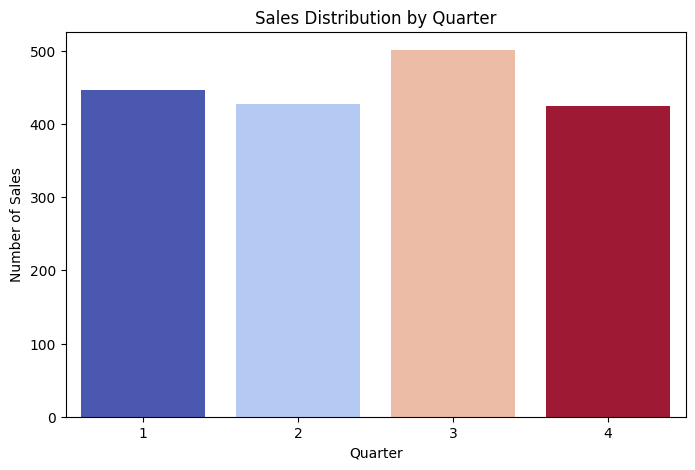

In [76]:
# Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
# Sales distribution over quarters
plt.figure(figsize=(8, 5))
sns.countplot(x="Quarter", data=df, palette="coolwarm", hue="Quarter", legend=False)
plt.title("Sales Distribution by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Number of Sales")
plt.show()


**Age Category vs Total Profit**


1.   It helps identify which age groups generate the most profit, guiding marketing and pricing strategies.


2.   Reveals if certain age groups make more frequent but lower-value purchases, or fewer but high-value purchases and assists in customer segmentation for personalized promotions.



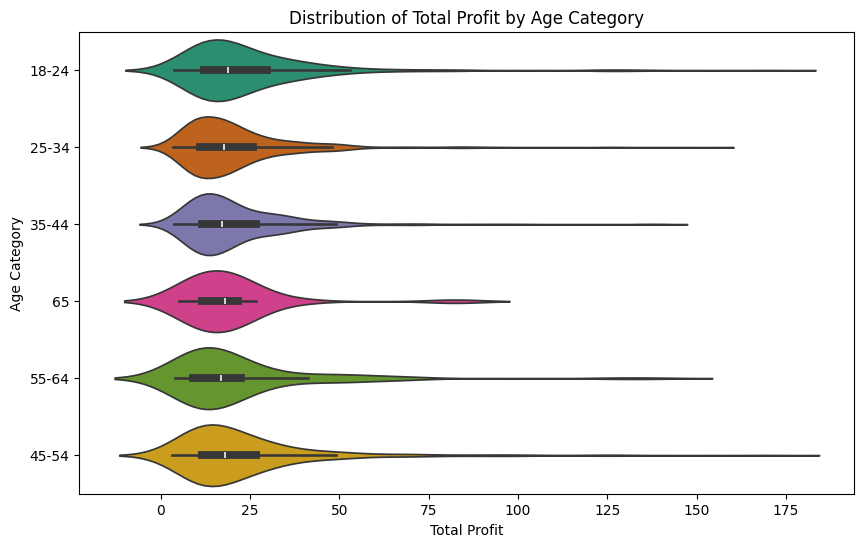

In [77]:
#  Age Category vs Total Profit
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Total Profit', y='Age Category', inner='box', hue='Age Category', palette='Dark2')
plt.title("Distribution of Total Profit by Age Category")
plt.show()

**Age Category vs Quantity**


1.   It determines which age groups buy in larger quantities.

2.   It helps retailers understand purchasing patterns.



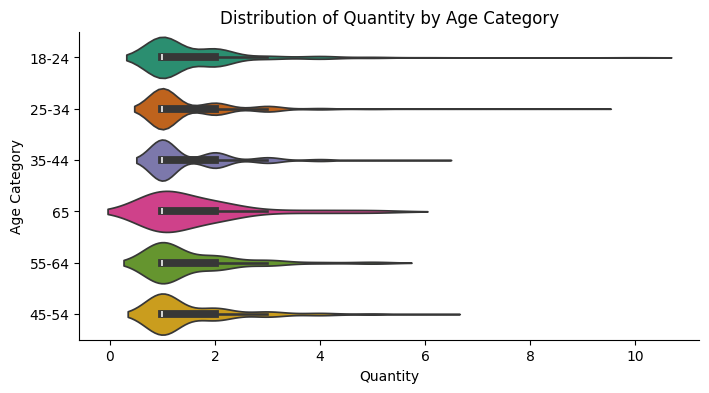

In [78]:
# Age Category vs Quantity
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='Quantity', y='Age Category', inner='box',palette='Dark2', hue='Age Category', legend=False)
sns.despine(top=True, right=True)
plt.title("Distribution of Quantity by Age Category")
plt.xlabel("Quantity")
plt.ylabel("Age Category")
plt.show()

**Age Category vs Total Price**


1.  It shows whether different age groups spend more or less and can target the wide range of age categorized customers.

2.   It is useful for targeted marketing strategies.



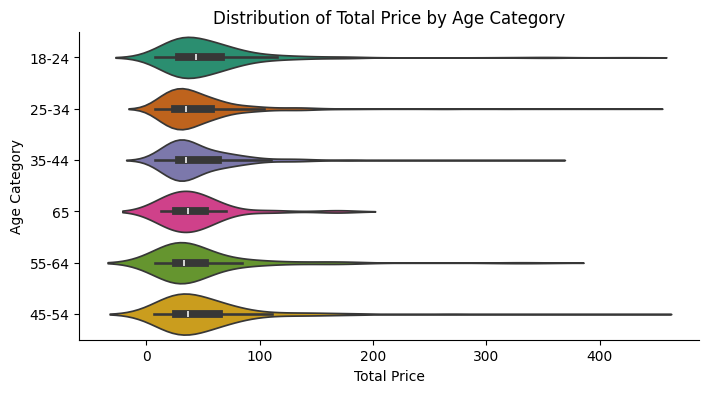

In [79]:
#  Age Category vs Total Price
plt.figure(figsize=(8, 4))
sns.violinplot(data=df, x='Total Price', y='Age Category', inner='box',palette='Dark2', hue='Age Category', legend=False)
sns.despine(top=True, right=True)
plt.title("Distribution of Total Price by Age Category")
plt.xlabel("Total Price")
plt.ylabel("Age Category")
plt.show()

**Total Price vs Total Profit**


1.   It determines if higher Total Prices correlate with higher profits.

2.   It will indicate whether some items are overpriced but not profitable and changes will be done for profit and customer satifaction.



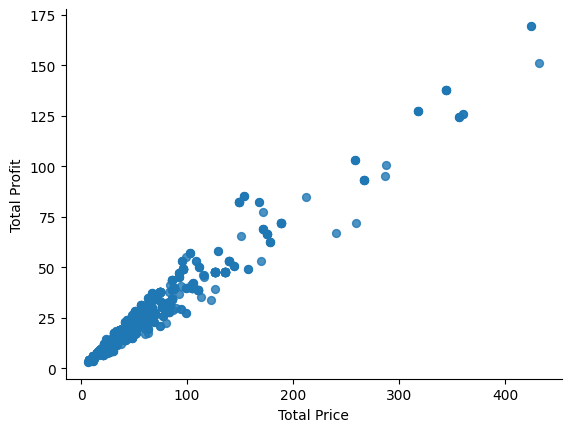

In [80]:
# Total Price vs Total Profit
df.plot(kind='scatter', x='Total Price', y='Total Profit', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

**Top 10 selling products**


1.   It let the  businesses understand which products drive the most sales.

2.   IT is useful for inventory management and promotions.



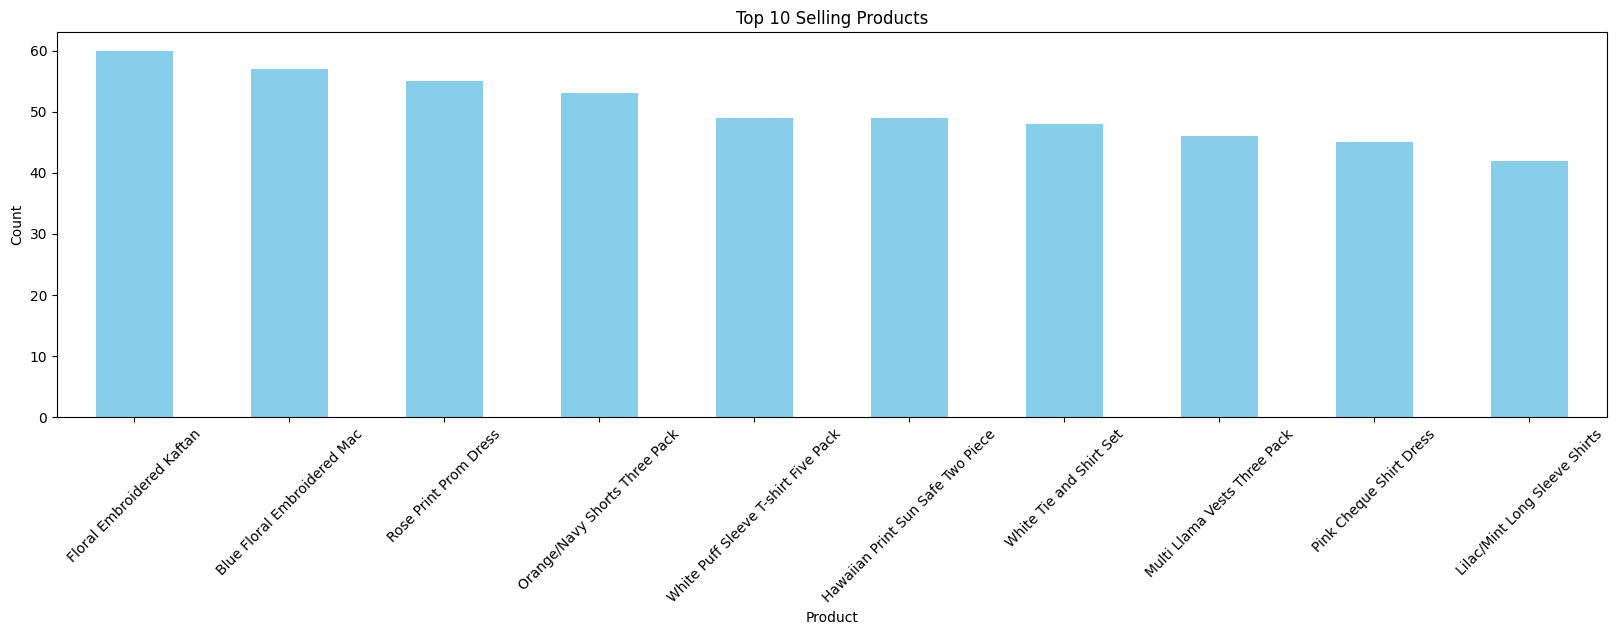

In [81]:
# Top 10 selling products
top_products = df["Product"].value_counts().nlargest(10)
plt.figure(figsize=(20, 5))
top_products.plot(kind="bar", color="skyblue")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Payment method analysis**


1.   It is used to identify popular payment methods among customers.

2.   It will be useful for optimizing transaction systems.



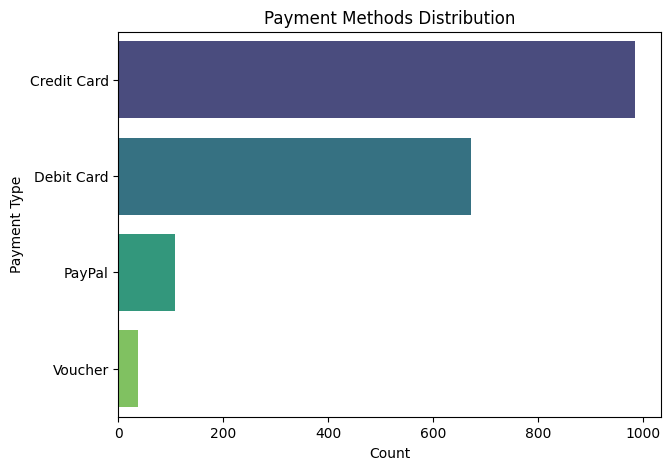

In [82]:
# Payment method analysis
plt.figure(figsize=(7, 5))
sns.countplot(y="Payment Type", data=df, palette="viridis", hue="Payment Type", order=df["Payment Type"].value_counts().index, legend=False)
plt.title("Payment Methods Distribution")
plt.xlabel("Count")
plt.ylabel("Payment Type")
plt.show()

**Profit distribution**


1.   It shows how profits vary across transactions.
2.   It helps to detect skewness and outliers in profit data.



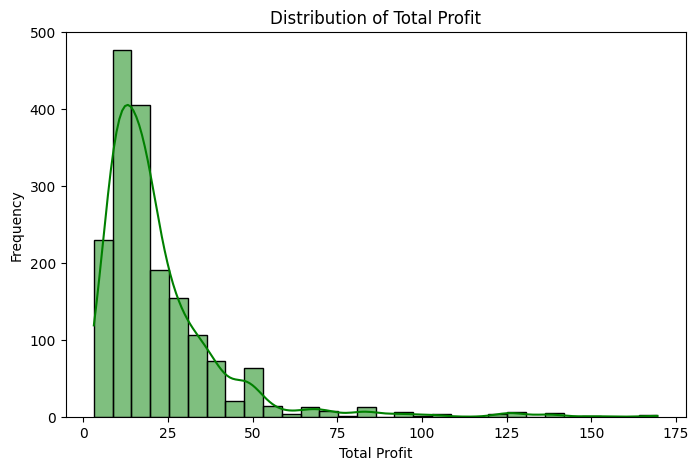

In [83]:
# Profit distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Total Profit"], bins=30, kde=True, color="green")
plt.title("Distribution of Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Frequency")
plt.show()

**Correlation heatmap**


1.   Shows relationships between numerical variables as in the below heatmap  Total Price vs Total Profit.

2.   It identifies dependencies like does higher Total Price lead to higher Total Profit?.



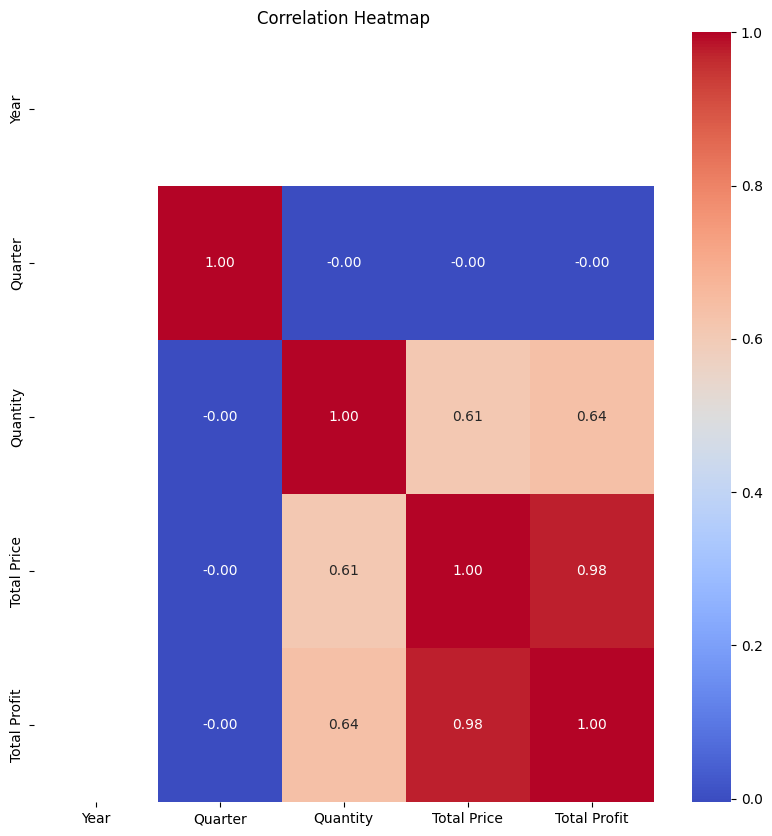

In [84]:
# Correlation heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Sales vs Location analysis**


1.   It identifies locations with the highest sales volume.

2.   It helps assess whether high sales correlate with high profits.



<ipython-input-85-11a23980d476>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Location', y='Total Price', data=df, estimator=sum, ci=None)


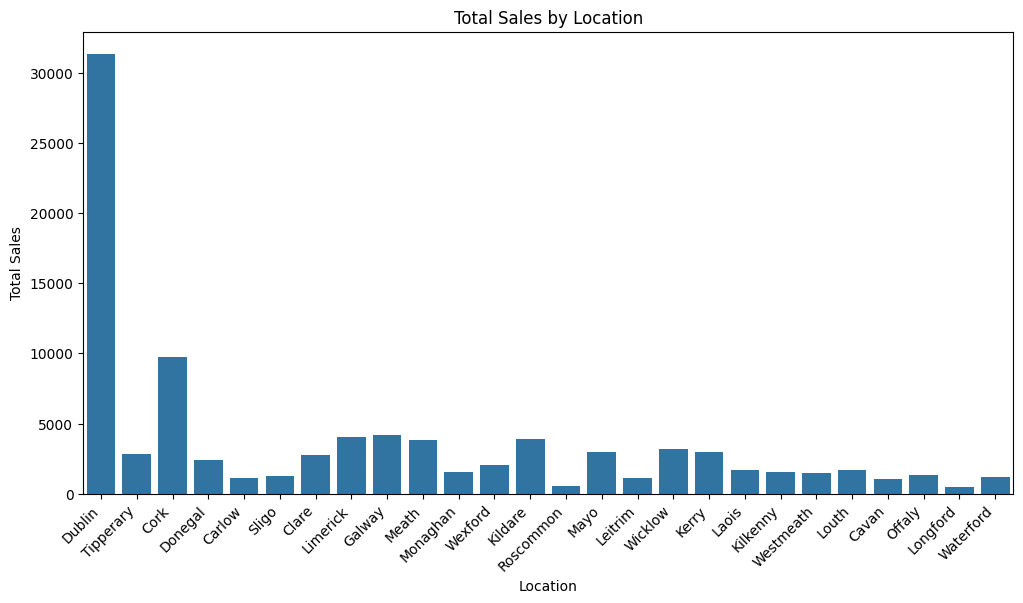

In [85]:
# Sales vs Location analysis
plt.figure(figsize=(12, 6))
sns.barplot(x='Location', y='Total Price', data=df, estimator=sum, ci=None)
plt.title('Total Sales by Location')
plt.xlabel('Location')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

**Sales distribution by Location**


1.   It shows the proportion of sales coming from different locations.

2.   It helps in understanding market concentration and regional demand.



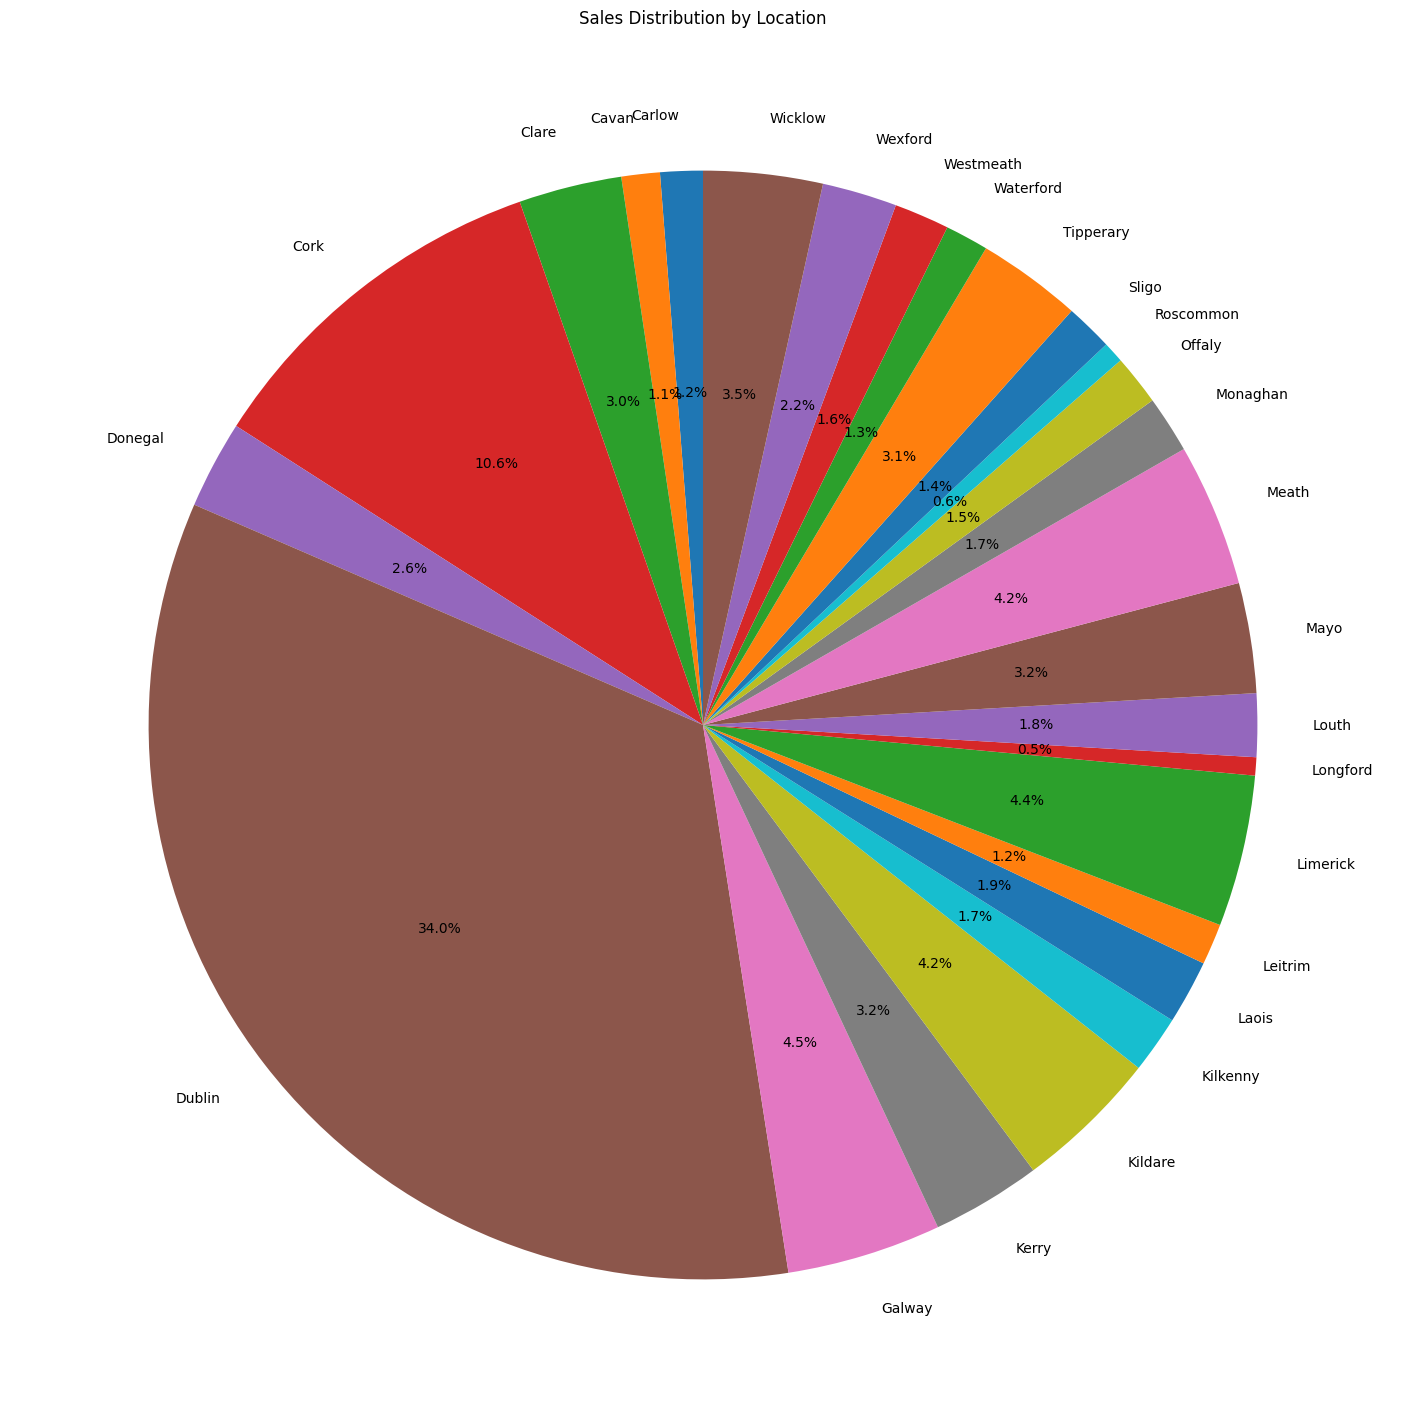

In [86]:
# Sales distribution by Location
location_sales = df.groupby('Location')['Total Price'].sum()
plt.figure(figsize=(18, 18))
plt.pie(location_sales, labels=location_sales.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Location')
plt.show()

**Profit by Location**


1.   Helps identify which locations generate the highest and lowest profits.
2.   Supports strategic decision-making like expanding in profitable areas orimproving performance in weak locations.



<ipython-input-87-73ea87f4c6fe>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Location', y='Total Profit', data=df, estimator=sum, ci=None)


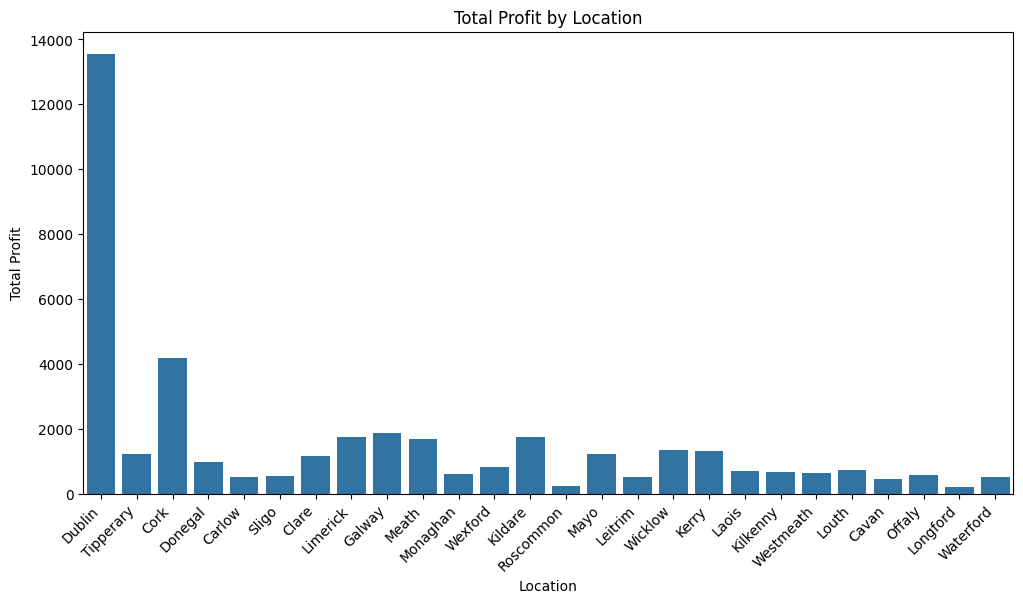

In [87]:
#  Profit by location
plt.figure(figsize=(12, 6))
sns.barplot(x='Location', y='Total Profit', data=df, estimator=sum, ci=None)
plt.title('Total Profit by Location')
plt.xlabel('Location')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.show()



---


**DISCUSSIONS**

**Challenges Faced in Scraping and Cleaning the Data**

1.   Inconsistent Data Formats



*   The "Date of Sale" column required conversion to a proper datetime format due to inconsistencies in date representation.
*  The "Total Price" and "Total Profit" columns had currency symbols (€), which needed to be removed before conversion to numeric format.




2.   Missing and Null Values


*   Several categorical fields such as "Location," "Gender," "Age Category" contained missing values. These were filled using the mode to maintain consistency.




3.   Duplicate Entries


*   Duplicate rows were detected and removed to ensure each transaction was unique and accurate.


4.   Negative or Unrealistic Values


*  Some values of"Quantity"  were negative, which could indicate data entry errors or returned products. These were either corrected or excluded based on their relevance.



5.   Standardizing Categorical Data


*   The "Payment Type" column had inconsistent abbreviations (e.g., "CC" instead of "Credit Card"), requiring standardization for clarity.


6.   Handling Missing Data in Scraping


*  Certain values like Location or Gender are missing, they are set to None in which earlier data cannot be extracted and retified




---










**Key Functionalities & Justifications in Scraping and Analysis**

**Analysis**

1.   Sales distribution across quarters showed a peak in specific periods, indicating seasonal trends which  could help optimize inventory and promotional strategies

2.   Certain products consistently outperformed others, providing insights into customer preferences and understanding these trends can help in product stocking and marketing strategies.

3.   Certain locations contributed more to total profits like dublin, highlighting key market segments and these insights could guide targeted marketing efforts.

4.   Analysis of payment methods revealed which options customers prefer, helping businesses optimize payment processing.

5.   A correlation heatmap provided insights into relationships between different variables, such as total price, profit, and quantity, these
strong correlations can aid in predicting future sales and profitability trends.

**Scraping**

1.   Identified and extracted tables with the "sale" class, where sales data is stored.


2.   Used regex to capture the year (YYYY) and quarter (Q1, Q2, etc.) from the URL which helps categorize sales data by time period.



3.   The script loops through multiple URLs to fetch data from different pages in which each request checks the status code to ensure successful retrieval.


4.   The script loops through <tr> (table rows) and <td> (table data cells) and
If a row has two cells, it assigns the first as a key and the second as a value.

5.   Some fields (Customer ID, Location, Gender, Age Category) are embedded within a single "Customer Details" field which uses regular expressions (regex) to extract these details individually.


6.   After extracting customer details, the original "Customer Details" field is deleted which  ensures a cleaner dataset with well-defined columns.


---




**Further Work and Potential Enhancements**

**Analysis**


1.   Incorporating external data such as customer demographics, marketing campaigns, or economic indicators could improve sales and profit predictions.
2.   Using machine learning models such as regression, decision trees to predict future sales based on past trends.

3.   Clustering techniques could help identify distinct customer groups based on purchasing behavior.
4.   If review data is available, analyzing customer sentiment could reveal factors influencing sales and customer satisfaction.

5.   Analyzing return data separately could help in identifying patterns and reducing return rates.

**Scraping**



1.     Instead of appending all the scraped data to a CSV,  storing it in a relational database (like SQLite, PostgreSQL, or MySQL) for better management and analysis.
2.   Set up a real-time data fetching system (using tools like Apache Kafka or Streamlit) to continuously scrape and update the database with the latest sales information.




---






